# Text2SQL 
### Natural Language → Database Queries | `qwen3.5:4b` + `qwen3-embedding:0.6b`


---
## Before You Begin

Pull models (run once in terminal):
```bash
ollama pull qwen3.5:4b
ollama pull qwen3-embedding:0.6b
```

### Critical: `think=False`

`qwen3.5:4b` is a thinking model. Without `think=False`, it wraps output inside
`<think>` tags and `.content` is empty — you get blank SQL.

**Rule:**
- Calls with a **system role** → system message anchors behavior, `think=False` optional
- Calls with **user message only** → always use `think=False`

In [3]:
# ── Cell 1: Install Dependencies ──────────────────────────────────────────────
# : Four libraries needed for this full pipeline.
#   ollama    -> call qwen3.5:4b (LLM) and qwen3-embedding:0.6b (embeddings)
#   chromadb  -> in-memory vector DB for Schema RAG (Section 7)
#   pandas    -> run SQL, display results as DataFrames
#   matplotlib -> generate charts (Section 10)

import subprocess, sys

packages = ["ollama", "chromadb", "pandas", "matplotlib"]

for pkg in packages:
    result = subprocess.run(
        [sys.executable, "-m", "pip", "install", pkg, "-q"],
        capture_output=True, text=True
    )
    print(f"{'OK' if result.returncode == 0 else 'FAIL'} {pkg}")

print("\nAll dependencies installed!")

OK ollama
OK chromadb
OK pandas
OK matplotlib

All dependencies installed!


In [4]:
# ── Cell 2: Configuration + Model Check ───────────────────────────────────────
# : Centralise model names. Fail fast if a model is missing.

import ollama

LLM_MODEL   = "qwen3.5:4b"           # SQL-generating brain
EMBED_MODEL = "qwen3-embedding:0.6b"  # Text -> numbers for similarity search

print("Checking models...")

# think=False is critical for qwen3.5:4b
# Without it: response goes into <think> tags and .content is empty
try:
    resp = ollama.chat(
        model=LLM_MODEL,
        messages=[{"role": "user", "content": "Reply: OK"}],
        think=False,
    )
    print(f"OK LLM    -> {LLM_MODEL}: {resp.message.content}")
except Exception as e:
    print(f"FAIL LLM: {e}")
    print(f"  Fix: ollama pull {LLM_MODEL}")

try:
    emb = ollama.embeddings(model=EMBED_MODEL, prompt="test")
    print(f"OK Embed  -> {EMBED_MODEL} ({len(emb.embedding)}-dim)")
except Exception as e:
    print(f"FAIL Embed: {e}")
    print(f"  Fix: ollama pull {EMBED_MODEL}")

print("\nConfiguration complete!")

Checking models...
OK LLM    -> qwen3.5:4b: OK! How can I assist you today?
OK Embed  -> qwen3-embedding:0.6b (1024-dim)

Configuration complete!


---
# Section 1 — Build the Database

##  

We build a Swiggy-like food delivery database — realistic enough to generate
meaningful business questions.

** realistic distributions?**
- 75% delivered, 20% cancelled, 5% placed — real food delivery stats
- 50% UPI, 25% Card, 15% COD, 10% Wallet — India payment landscape
- Orders across 60 days — so date queries return actual results

## The 5-Table Structure

```
restaurants <------- orders <------ order_items
                         |
customers ---------------+
                         |
reviews -----------------+
```

## Key Note: `orders` Has No `city` Column

The most common LLM mistake: `WHERE orders.city = "Mumbai"`

`city` is on `restaurants`, not `orders`. To get Mumbai orders:
```sql
-- WRONG:  WHERE orders.city = "Mumbai"
-- RIGHT:  JOIN restaurants r ON o.restaurant_id = r.id WHERE r.city = "Mumbai"
```

Section 2 shows how the schema description prevents this.

In [5]:
# ── Cell 3: Create SQLite Database ────────────────────────────────────────────
# : SQLite = zero setup, runs in a file, supports full SQL.
# HOW: Create schema then seed with realistic distributions.
#      random.seed(42) = same database for every student.

import sqlite3, pandas as pd, random, os
from datetime import datetime, timedelta

DB_PATH = "./swiggy_demo.db"
if os.path.exists(DB_PATH):
    os.remove(DB_PATH)  # idempotent — safe to re-run

conn = sqlite3.connect(DB_PATH)
cur  = conn.cursor()

# DESIGN DECISION: SQL comments on every column.
# These appear in schema introspection and help both humans and LLMs.
cur.executescript("""
CREATE TABLE restaurants (
    id INTEGER PRIMARY KEY, name TEXT NOT NULL,
    city TEXT NOT NULL,    -- values: Mumbai,Delhi,Bangalore,Hyderabad,Chennai
    cuisine TEXT NOT NULL, -- values: Indian,Chinese,Italian,Fast Food,South Indian
    rating REAL,           -- avg customer rating 1.0-5.0
    is_active INTEGER DEFAULT 1  -- 1=open, 0=closed
);
CREATE TABLE customers (
    id INTEGER PRIMARY KEY, name TEXT NOT NULL,
    city TEXT NOT NULL, email TEXT UNIQUE NOT NULL,
    joined_date TEXT NOT NULL  -- format: YYYY-MM-DD
);
CREATE TABLE orders (
    id INTEGER PRIMARY KEY,
    customer_id INTEGER REFERENCES customers(id),
    restaurant_id INTEGER REFERENCES restaurants(id),
    total_amount REAL NOT NULL,  -- GMV in rupees
    status TEXT NOT NULL,        -- values: delivered, cancelled, placed
    payment_mode TEXT NOT NULL,  -- values: UPI, Card, COD, Wallet
    created_at TEXT NOT NULL,    -- format: YYYY-MM-DD HH:MM:SS
    delivered_at TEXT            -- NULL if not delivered
);
CREATE TABLE order_items (
    id INTEGER PRIMARY KEY,
    order_id INTEGER REFERENCES orders(id),
    item_name TEXT NOT NULL,   -- e.g. Biryani, Burger, Pizza, Dosa
    quantity INTEGER NOT NULL,
    unit_price REAL NOT NULL   -- price per item in rupees
);
CREATE TABLE reviews (
    id INTEGER PRIMARY KEY,
    order_id INTEGER REFERENCES orders(id),
    restaurant_id INTEGER REFERENCES restaurants(id),
    customer_id INTEGER REFERENCES customers(id),
    rating INTEGER NOT NULL,  -- 1 to 5
    comment TEXT,
    created_at TEXT NOT NULL
);
""")

random.seed(42)  # fixed seed = reproducible data across all students
cities   = ["Mumbai", "Delhi", "Bangalore", "Hyderabad", "Chennai"]
cuisines = ["Indian", "Chinese", "Italian", "Fast Food", "South Indian"]
rest_names = [
    "Spice Garden", "Dragon Palace", "Pizza Corner", "Burger Hub", "Dosa Express",
    "Biryani House", "Noodle World", "Tandoor Nights", "The Curry Bowl", "Pasta Primo",
    "Wok & Roll", "Masala Twist", "Street Bites", "Royal Kitchen", "Fresh Box"
]

restaurants = [
    (i+1, name, random.choice(cities), random.choice(cuisines),
     round(random.uniform(2.5, 5.0), 1), 1)
    for i, name in enumerate(rest_names)
]
cur.executemany("INSERT INTO restaurants VALUES (?,?,?,?,?,?)", restaurants)

customers_data = []
for i in range(200):
    joined = (datetime.now() - timedelta(days=random.randint(30, 730))).strftime("%Y-%m-%d")
    customers_data.append((i+1, f"Customer_{i+1}", random.choice(cities),
                           f"user{i+1}@example.com", joined))
cur.executemany("INSERT INTO customers VALUES (?,?,?,?,?)", customers_data)

# 75% delivered, 20% cancelled, 5% placed
statuses = ["delivered"]*75 + ["cancelled"]*20 + ["placed"]*5
payments = ["UPI"]*50 + ["Card"]*25 + ["COD"]*15 + ["Wallet"]*10
orders_data = []
for i in range(1200):
    created = (datetime.now() - timedelta(
        days=random.randint(0, 60), minutes=random.randint(0, 1440)
    )).strftime("%Y-%m-%d %H:%M:%S")
    status = random.choice(statuses)
    delivered = (
        datetime.strptime(created, "%Y-%m-%d %H:%M:%S") +
        timedelta(minutes=random.randint(20, 90))
    ).strftime("%Y-%m-%d %H:%M:%S") if status == "delivered" else None
    orders_data.append((i+1, random.randint(1,200), random.randint(1,15),
                        round(random.uniform(150,1200),2), status,
                        random.choice(payments), created, delivered))
cur.executemany("INSERT INTO orders VALUES (?,?,?,?,?,?,?,?)", orders_data)

food_items = ["Biryani","Butter Chicken","Dal Makhani","Naan","Paneer Tikka",
              "Fried Rice","Noodles","Pasta","Pizza","Burger","Dosa","Idli"]
all_items, item_id = [], 1
for order in orders_data:
    for _ in range(random.randint(1, 4)):
        all_items.append((item_id, order[0], random.choice(food_items),
                         random.randint(1,3), round(random.uniform(50,350),2)))
        item_id += 1
cur.executemany("INSERT INTO order_items VALUES (?,?,?,?,?)", all_items[:5000])

delivered_ords = [o for o in orders_data if o[4] == "delivered"]
comments = ["Great food!","Fast delivery.","Average.","Will order again.",
            "Cold food.","Excellent!","Okay.","Loved it!",None,None]
reviews_data = [
    (i+1, o[0], o[2], o[1], random.randint(2,5), random.choice(comments), o[6])
    for i, o in enumerate(random.sample(delivered_ords, min(600, len(delivered_ords))))
]
cur.executemany("INSERT INTO reviews VALUES (?,?,?,?,?,?,?)", reviews_data)
conn.commit()

print("Database created:", DB_PATH)
for tbl in ["restaurants", "customers", "orders", "order_items", "reviews"]:
    n = cur.execute(f"SELECT COUNT(*) FROM {tbl}").fetchone()[0]
    print(f"  {tbl:<20}: {n:>5} rows")

Database created: ./swiggy_demo.db
  restaurants         :    15 rows
  customers           :   200 rows
  orders              :  1200 rows
  order_items         :  2968 rows
  reviews             :   600 rows


In [6]:
# ── Cell 4: Explore the Schema ────────────────────────────────────────────────
# : Understand your schema before building Text2SQL. You cannot prompt
#      for columns you have not read.

print("=" * 60)
print("DATABASE SCHEMA")
print("=" * 60)
for tbl in ["restaurants", "customers", "orders", "order_items", "reviews"]:
    cols = conn.execute(f"PRAGMA table_info({tbl})").fetchall()
    print(f"\nTable: {tbl}")
    for c in cols:
        pk = " [PK]" if c[5] else ""
        nn = " NOT NULL" if c[3] else ""
        print(f"  {c[1]:<20} {c[2]:<12}{pk}{nn}")

print("\n" + "=" * 60 + "\nSAMPLE DATA")
for tbl in ["restaurants", "orders"]:
    print(f"\n{tbl} (first 3 rows):")
    print(pd.read_sql(f"SELECT * FROM {tbl} LIMIT 3", conn).to_string(index=False))

# Note: orders table has NO city column.
# city is on restaurants. This causes the most common LLM SQL mistake.

DATABASE SCHEMA

Table: restaurants
  id                   INTEGER      [PK]
  name                 TEXT         NOT NULL
  city                 TEXT         NOT NULL
  cuisine              TEXT         NOT NULL
  rating               REAL        
  is_active            INTEGER     

Table: customers
  id                   INTEGER      [PK]
  name                 TEXT         NOT NULL
  city                 TEXT         NOT NULL
  email                TEXT         NOT NULL
  joined_date          TEXT         NOT NULL

Table: orders
  id                   INTEGER      [PK]
  customer_id          INTEGER     
  restaurant_id        INTEGER     
  total_amount         REAL         NOT NULL
  status               TEXT         NOT NULL
  payment_mode         TEXT         NOT NULL
  created_at           TEXT         NOT NULL
  delivered_at         TEXT        

Table: order_items
  id                   INTEGER      [PK]
  order_id             INTEGER     
  item_name            TEXT         

---
# Section 2 — Schema Design for LLMs

## The #1 Factor in SQL Accuracy

The LLM already knows SQL. It does not know your schema.

**Bad description:**
```
orders: id, cid, rid, amt, st, pm, dat
```
LLM must guess: what is `cid`? What values does `st` accept?

**Good description:**
```
Table: orders
  customer_id   INTEGER  -- FK -> customers.id
  total_amount  REAL     -- GMV in rupees
  status        TEXT     -- values: delivered, cancelled, placed
  payment_mode  TEXT     -- values: UPI, Card, COD, Wallet
  created_at    TEXT     -- format: YYYY-MM-DD HH:MM:SS
```

## The 4 Rules

| Rule | Example |  |
|------|---------|-----|
| Column comments | `-- GMV in rupees` | Business meaning not in column name |
| Enum values | `-- values: UPI, Card, COD` | LLM needs exact strings to filter |
| Date formats | `-- format: YYYY-MM-DD HH:MM:SS` | SQLite date functions need exact format |
| FK labels | `-- FK -> customers.id` | Prevents wrong JOINs |

## Key Takeaway

> Improving your schema description string has more impact than changing models or adding examples. Always do this first.

In [7]:
# ── Cell 5: Schema Description (The Most Important Cell) ──────────────────────
# : Goes into every LLM prompt. Quality here = quality of SQL.
# HOW: Column comments + enum values + FK labels + SQLite date functions.

SCHEMA_DESCRIPTION = '''
Database: SQLite

Table: restaurants
  id        INTEGER PRIMARY KEY
  name      TEXT               -- restaurant name
  city      TEXT               -- values: Mumbai,Delhi,Bangalore,Hyderabad,Chennai
  cuisine   TEXT               -- values: Indian,Chinese,Italian,Fast Food,South Indian
  rating    REAL               -- average customer rating 1.0-5.0
  is_active INTEGER            -- 1=open, 0=closed

Table: customers
  id          INTEGER PRIMARY KEY
  name        TEXT
  city        TEXT               -- same city values as restaurants
  email       TEXT
  joined_date TEXT               -- format: YYYY-MM-DD

Table: orders
  id            INTEGER PRIMARY KEY
  customer_id   INTEGER            -- FK -> customers.id
  restaurant_id INTEGER            -- FK -> restaurants.id
  total_amount  REAL               -- GMV (gross merchandise value) in rupees
  status        TEXT               -- values: delivered,cancelled,placed
  payment_mode  TEXT               -- values: UPI,Card,COD,Wallet
  created_at    TEXT               -- format: YYYY-MM-DD HH:MM:SS
  delivered_at  TEXT               -- NULL if not yet delivered; same format

Table: order_items
  id         INTEGER PRIMARY KEY
  order_id   INTEGER            -- FK -> orders.id
  item_name  TEXT               -- e.g. Biryani,Burger,Pizza,Dosa
  quantity   INTEGER
  unit_price REAL               -- price per item in rupees

Table: reviews
  id            INTEGER PRIMARY KEY
  order_id      INTEGER  -- FK -> orders.id
  restaurant_id INTEGER  -- FK -> restaurants.id
  customer_id   INTEGER  -- FK -> customers.id
  rating        INTEGER  -- customer rating 1 to 5
  comment       TEXT     -- can be NULL
  created_at    TEXT     -- format: YYYY-MM-DD HH:MM:SS

SQLite date functions (use exactly):
  DATE('now')                                              -- today
  DATE('now', '-7 days')                                   -- 7 days ago
  strftime('%Y-%m', created_at)                            -- YYYY-MM from timestamp
  (julianday(delivered_at) - julianday(created_at))*24*60  -- minutes between dates
'''

print("Schema description ready.")
print(f"  Length: {len(SCHEMA_DESCRIPTION)} chars (~{len(SCHEMA_DESCRIPTION)//4} tokens)")
print()
print("Design decisions:")
print("  OK Column comments (total_amount = GMV in rupees)")
print("  OK Enum values for status, payment_mode, city, cuisine")
print("  OK Date format stated (YYYY-MM-DD HH:MM:SS)")
print("  OK FK relationships marked (FK -> restaurants.id)")
print("  OK SQLite date functions listed")
print()
print("Without these:")
print("  FAIL: LLM writes status='Delivered' instead of status='delivered'")
print("  FAIL: LLM writes DATE_FORMAT() instead of strftime()")

Schema description ready.
  Length: 2086 chars (~521 tokens)

Design decisions:
  OK Column comments (total_amount = GMV in rupees)
  OK Enum values for status, payment_mode, city, cuisine
  OK Date format stated (YYYY-MM-DD HH:MM:SS)
  OK FK relationships marked (FK -> restaurants.id)
  OK SQLite date functions listed

Without these:
  FAIL: LLM writes status='Delivered' instead of status='delivered'
  FAIL: LLM writes DATE_FORMAT() instead of strftime()


---
# Section 3 — Basic SQL Generation

## How Text2SQL Works

```
System role:  Schema + Rules  (set once, every query)
User role:    The question    (changes per query)
      |
      v
   qwen3.5:4b
      |
      v
  "SELECT COUNT(*) FROM orders;"  (with extra text we strip)
```

## The SQL Extraction Challenge

LLMs add explanation around the SQL:
```
"Here is the query:
```sql
SELECT COUNT(*) FROM orders;
```
This counts all rows."
```

`extract_sql()` handles 5 formats: think tags, markdown fences, preamble, no semicolon, multi-line.

## When to Use `think=False`

| Call structure | `think=False` needed? |
|---------------|----------------------|
| system + user message | No — system anchors behavior |
| user message only | YES — output goes into `<think>` tags otherwise |

In [8]:
# ── Cell 6: SQL Extraction + Basic Generation ─────────────────────────────────
# : LLMs don't return clean SQL. Robust extraction is needed before execution.
# HOW: Multi-step regex pipeline, each step handles one output format.

import re

def extract_sql(text: str) -> str:
    """Extract clean SQL from any LLM output format."""
    if not text:
        return ""
    # Step 1: Remove <think> blocks (qwen3 thinking mode)
    text = re.sub(r"<think>.*?</think>", "", text, flags=re.DOTALL).strip()
    # Step 2: Remove markdown code fences
    text = re.sub(r"```sql\s*", "", text, flags=re.IGNORECASE)
    text = re.sub(r"```\s*", "", text).strip()
    # Step 3: Find SELECT...;  (primary path, works 90% of the time)
    m = re.search(r"(SELECT\b.+?;)", text, re.DOTALL | re.IGNORECASE)
    if m:
        return m.group(1).strip()
    # Step 4: Line-by-line when semicolon is missing
    lines, sql_lines, cap = text.split("\n"), [], False
    for line in lines:
        if re.match(r"^\s*SELECT\b", line, re.IGNORECASE):
            cap = True
        if cap:
            sql_lines.append(line)
            if line.strip().endswith(";"):
                break
    if sql_lines:
        return "\n".join(sql_lines).strip()
    # Step 5: Last resort
    return text.strip()


SYSTEM_PROMPT_BASIC = f"""You are a SQLite expert. Generate accurate SQL queries.

DATABASE SCHEMA:
{SCHEMA_DESCRIPTION}

RULES:
1. Write ONLY SELECT queries (never INSERT, UPDATE, DELETE, DROP, ALTER)
2. Use SQLite syntax (strftime not DATE_FORMAT, julianday for time diff)
3. Column names MUST match the schema exactly
4. Return ONLY the SQL — no explanation, no markdown
5. End with semicolon; add LIMIT 100 for queries returning many rows"""


def generate_sql(question: str) -> str:
    """Generate SQL from a natural language question."""
    resp = ollama.chat(
        model=LLM_MODEL,
        messages=[
            {"role": "system", "content": SYSTEM_PROMPT_BASIC},
            {"role": "user",   "content": question},
        ]
        # No think=False needed here — system message anchors behavior
    )
    return extract_sql(resp.message.content or "")


def run_sql(sql: str, connection=None):
    """Execute SQL, return DataFrame or error string."""
    try:
        return pd.read_sql(sql, connection or conn)
    except Exception as e:
        return f"SQL Error: {e}"


# Verify extract_sql works
messy = "Here is the query:\n```sql\nSELECT COUNT(*) FROM orders;\n```\nThis counts all rows."
print("extract_sql() test:")
print(f"  Input:  {repr(messy[:60])}...")
print(f"  Output: {repr(extract_sql(messy))}")
print("  OK!")

extract_sql() test:
  Input:  'Here is the query:\n```sql\nSELECT COUNT(*) FROM orders;\n```\nT'...
  Output: 'SELECT COUNT(*) FROM orders;'
  OK!


In [9]:
# ── Cell 7: Test Basic SQL Generation ─────────────────────────────────────────
# Read the generated SQL carefully. Do the column names match the schema?

test_questions = [
    "How many total orders are in the database?",
    "What is the average order value in rupees?",
    "How many orders were cancelled?",
    "Which city has the most restaurants?",
]

print("Basic Text2SQL Demo")
print("=" * 65)

for q in test_questions:
    print(f"\nQ: {q}")
    sql = generate_sql(q)
    print(f"SQL: {sql}")
    result = run_sql(sql)
    if isinstance(result, pd.DataFrame):
        print(result.to_string(index=False))
    else:
        print(result)

Basic Text2SQL Demo

Q: How many total orders are in the database?
SQL: SELECT COUNT(*) AS total_orders FROM orders LIMIT 100;
 total_orders
         1200

Q: What is the average order value in rupees?
SQL: SELECT AVG(total_amount) FROM orders;
 AVG(total_amount)
          674.4294

Q: How many orders were cancelled?
SQL: SELECT COUNT(*) AS cancelled_order_count FROM orders WHERE status = 'cancelled';
 cancelled_order_count
                   267

Q: Which city has the most restaurants?
SQL: SELECT city FROM restaurants GROUP BY city ORDER BY COUNT(*) DESC LIMIT 1;
  city
Mumbai


---
# Section 4 — Security Validation

##  Security Is Non-Negotiable

Without validation, a user can ask:
- *"Delete all orders"* — `DELETE FROM orders;` — irreversible
- *"Drop the database"* — `DROP TABLE restaurants;` — catastrophic

## Three-Layer Defense

```
Layer 1: SQL Whitelist — only SELECT queries allowed (validate_sql)
Layer 2: Read-Only DB Connection — OS-level write protection (mode=ro)
Layer 3: LIMIT Enforcement — prevent full-table returns (LIMIT 100)
```

## Whitelist vs Blacklist

```python
# Blacklist (BAD): enumerate all bad patterns
if "DROP" in sql or "DELETE" in sql or ...  # easy to bypass

# Whitelist (GOOD): allow ONLY known-safe operations
if not sql.strip().upper().startswith("SELECT"):
    return False   # everything else blocked
```

## `mode=ro` — OS-Level Protection

```python
uri = "file:swiggy_demo.db?mode=ro"
conn = sqlite3.connect(uri, uri=True)
```

SQLite opens the file read-only at the OS level. Even buggy application code
cannot write through this connection.

> Production rule: Run Text2SQL against a read replica, never the primary DB.

In [10]:
# ── Cell 8: SQL Security Validation ──────────────────────────────────────────
# : LLM can generate dangerous SQL. Validate BEFORE executing.
# HOW: Whitelist (SELECT only) + forbidden pattern check.

import urllib.parse

FORBIDDEN_PATTERNS = [
    r"\bDELETE\b", r"\bDROP\b",   r"\bTRUNCATE\b",
    r"\bINSERT\b", r"\bUPDATE\b", r"\bALTER\b",
    r"\bCREATE\b", r"\bGRANT\b",  r"\bREVOKE\b",
    r"\bATTACH\b", r"\bDETACH\b", r"\bPRAGMA\b",
    r"--",           r";.*;",          r"\bLOAD_EXTENSION\b",
]


def validate_sql(sql: str) -> tuple:
    """Validate SQL before execution. Returns (is_safe, reason)."""
    if not sql or not sql.strip():
        return False, "Empty SQL"
    u = sql.strip().upper()
    if not u.startswith("SELECT"):
        return False, f"Must start with SELECT — got: {u[:25]!r}"
    for pat in FORBIDDEN_PATTERNS:
        if re.search(pat, u):
            return False, f"Forbidden keyword: {re.search(pat, u).group()}"
    return True, "OK"


def get_readonly_conn(db_path: str):
    """Open a read-only SQLite connection (URI mode=ro).
    Writes are physically blocked at the OS level.
    """
    uri = f"file:{urllib.parse.quote(os.path.abspath(db_path))}?mode=ro"
    return sqlite3.connect(uri, uri=True)


ro_conn = get_readonly_conn(DB_PATH)  # use for all query execution


test_cases = [
    ("SELECT COUNT(*) FROM orders;",              "PASS"),
    ("SELECT * FROM customers;",                  "PASS"),
    ("DELETE FROM orders WHERE id < 100;",        "FAIL"),
    ("SELECT * FROM orders; DROP TABLE orders;",  "FAIL"),
    ("UPDATE orders SET status=\'cancelled\';",    "FAIL"),
    ("PRAGMA table_info(orders);",                "FAIL"),
    ("",                                          "FAIL"),
]

print("SQL Validation Tests")
print("=" * 65)
for sql, expected in test_cases:
    safe, reason = validate_sql(sql)
    icon  = "OK" if safe else "NO"
    got   = "PASS" if safe else "FAIL"
    match = "correct" if got == expected else "WRONG!"
    display = (sql[:50] + "...") if len(sql) > 50 else sql
    print(f"  {icon} [{match}] {display}")
    if not safe:
        print(f"        -> {reason}")

SQL Validation Tests
  OK [correct] SELECT COUNT(*) FROM orders;
  OK [correct] SELECT * FROM customers;
  NO [correct] DELETE FROM orders WHERE id < 100;
        -> Must start with SELECT — got: 'DELETE FROM ORDERS WHERE '
  NO [correct] SELECT * FROM orders; DROP TABLE orders;
        -> Forbidden keyword: DROP
  NO [correct] UPDATE orders SET status='cancelled';
        -> Must start with SELECT — got: 'UPDATE ORDERS SET STATUS='
  NO [correct] PRAGMA table_info(orders);
        -> Must start with SELECT — got: 'PRAGMA TABLE_INFO(ORDERS)'
  NO [correct] 
        -> Empty SQL


---
# Section 5 — Auto-Fix Pipeline

## LLMs Make SQL Mistakes — That Is Normal

| Error | Wrong SQL | Cause |
|-------|-----------|-------|
| Wrong table | `WHERE orders.city = "Mumbai"` | city is on restaurants |
| MySQL syntax | `DATE_FORMAT(created_at, "%Y-%m")` | SQLite uses strftime |
| Column typo | `order_amount` | Correct: `total_amount` |

## The Fix Strategy

```
Error: "no such column: orders.city"
    |
    v
Send: broken_sql + error_message + question -> LLM
    |
    v
LLM: "The error says orders.city does not exist.
      city is on restaurants. I need a JOIN."
    |
    v
Fixed: JOIN restaurants r ON o.restaurant_id = r.id WHERE r.city = "Mumbai"
```

Error messages are information. This handles **80–85% of SQL errors** on the first retry.

> Note: `think=False` required in `fix_sql()` — it uses a single-message call.

In [11]:
# ── Cell 9: Auto-Fix Pipeline ─────────────────────────────────────────────────
# : Even with a good schema, small LLMs make SQL mistakes.
# HOW: Catch the error, pass (bad_sql + error + question) to LLM, retry.

def fix_sql(bad_sql: str, error_msg: str, question: str) -> str:
    """Ask the LLM to fix broken SQL given the error message.
    think=False required: single-message call.
    """
    fix_prompt = f"""Fix this SQL error. Return ONLY the corrected SQL.

Original question: {question}
Broken SQL: {bad_sql}
Error: {error_msg}
Corrected SQL:"""

    resp = ollama.chat(
        model=LLM_MODEL,
        think=False,
        messages=[
            {"role": "system", "content": SYSTEM_PROMPT_BASIC},
            {"role": "user",   "content": fix_prompt},
        ]
    )
    return extract_sql(resp.message.content or "")


def execute_with_autofix(question: str, sql: str, max_retries: int = 2) -> tuple:
    """Execute SQL with auto-fix on error.
    Returns: (DataFrame or None, final_sql, attempt_log)
    """
    attempts, current_sql = [], sql
    for attempt in range(max_retries + 1):
        safe, reason = validate_sql(current_sql)
        if not safe:
            attempts.append(f"Attempt {attempt+1}: BLOCKED - {reason}")
            return None, current_sql, attempts
        try:
            df = pd.read_sql(current_sql, ro_conn)
            attempts.append(f"Attempt {attempt+1}: SUCCESS ({len(df)} rows)")
            return df, current_sql, attempts
        except Exception as e:
            attempts.append(f"Attempt {attempt+1}: ERROR - {e}")
            if attempt < max_retries:
                print(f"    Error: {e}")
                print(f"    Auto-fixing...")
                current_sql = fix_sql(current_sql, str(e), question)
                print(f"    Fixed SQL: {current_sql[:60]}...")
    return None, current_sql, attempts


# Demo: deliberately wrong SQL
print("Auto-Fix Demo")
print("=" * 65)
question   = "How many orders from Mumbai restaurants?"
broken_sql = "SELECT COUNT(*) FROM orders WHERE orders.city = \'Mumbai\';"
print(f"Question:    {question}")
print(f"Broken SQL:  {broken_sql}")
print()
df, final_sql, log = execute_with_autofix(question, broken_sql)
print("\nResult:")
for e in log: print(f"  -> {e}")
print(f"\nFinal SQL: {final_sql}")
if df is not None:
    print("\nResult:")
    print(df.to_string(index=False))

Auto-Fix Demo
Question:    How many orders from Mumbai restaurants?
Broken SQL:  SELECT COUNT(*) FROM orders WHERE orders.city = 'Mumbai';

    Error: Execution failed on sql 'SELECT COUNT(*) FROM orders WHERE orders.city = 'Mumbai';': no such column: orders.city
    Auto-fixing...
    Fixed SQL: SELECT COUNT(*) FROM orders o JOIN restaurants r ON o.restau...

Result:
  -> Attempt 1: ERROR - Execution failed on sql 'SELECT COUNT(*) FROM orders WHERE orders.city = 'Mumbai';': no such column: orders.city
  -> Attempt 2: SUCCESS (1 rows)

Final SQL: SELECT COUNT(*) FROM orders o JOIN restaurants r ON o.restaurant_id = r.id WHERE r.city = 'Mumbai' LIMIT 100;

Result:
 COUNT(*)
      392


---
# Section 6 — Few-Shot Prompting

## What Examples Teach

NOT SQL syntax — the LLM already knows that.

They teach **your conventions**:

| Without examples | With examples |
|-----------------|---------------|
| `AVG(delivery_time)` — column does not exist | `AVG((julianday(delivered_at) - julianday(created_at)) * 24 * 60)` |
| `WHERE status="Cancelled"` — wrong case | `WHERE status="delivered"` — exact match |
| `orders.gmv` — wrong name | `orders.total_amount` — from example |

## How to Choose 5 Examples

Cover these patterns (appear in 80% of business questions):

1. **Date filter** — teaches `DATE("now", "-N days")`
2. **JOIN + SUM** — teaches the correct `restaurant_id` JOIN path
3. **CASE WHEN rate** — teaches percentage calculations
4. **julianday() time diff** — SQLite-specific delivery time formula
5. **order_items aggregate** — teaches which table for food-level queries

> Rule: If a query type fails more than twice in testing, add it as an example.

In [12]:
# ── Cell 10: Few-Shot Examples + Enhanced Prompt ──────────────────────────────
# : 5 examples cover 80% of business query patterns.
# HOW: Include examples in the system prompt — LLM pattern-matches on them.

FEW_SHOT_EXAMPLES = [
    {
        "question": "How many orders were placed today?",
        # TEACHES: SQLite date comparison
        "sql": "SELECT COUNT(*) AS orders_today FROM orders WHERE DATE(created_at) = DATE('now');"
    },
    {
        "question": "Top 5 restaurants by total GMV in the last 30 days?",
        # TEACHES: correct JOIN path, SUM, date range, LIMIT
        "sql": (
            "SELECT r.name, ROUND(SUM(o.total_amount), 2) AS total_gmv\n"
            "FROM orders o\n"
            "JOIN restaurants r ON o.restaurant_id = r.id\n"
            "WHERE o.status = 'delivered' AND DATE(o.created_at) >= DATE('now', '-30 days')\n"
            "GROUP BY r.name ORDER BY total_gmv DESC LIMIT 5;"
        )
    },
    {
        "question": "Cancellation rate by payment method?",
        # TEACHES: CASE WHEN for conditional aggregation
        "sql": (
            "SELECT payment_mode,\n"
            "       ROUND(100.0 * SUM(CASE WHEN status='cancelled' THEN 1 ELSE 0 END)\n"
            "             / COUNT(*), 2) AS cancellation_pct\n"
            "FROM orders GROUP BY payment_mode ORDER BY cancellation_pct DESC;"
        )
    },
    {
        "question": "Average delivery time in minutes by city?",
        # TEACHES: julianday() — the ONLY way to compute time diff in SQLite
        "sql": (
            "SELECT r.city,\n"
            "       ROUND(AVG((julianday(o.delivered_at) - julianday(o.created_at)) * 24 * 60), 1)\n"
            "       AS avg_delivery_minutes\n"
            "FROM orders o JOIN restaurants r ON o.restaurant_id = r.id\n"
            "WHERE o.status = 'delivered' AND o.delivered_at IS NOT NULL\n"
            "GROUP BY r.city ORDER BY avg_delivery_minutes;"
        )
    },
    {
        "question": "Top 3 most ordered food items?",
        # TEACHES: use order_items for food-level queries (not orders table)
        "sql": "SELECT item_name, SUM(quantity) AS total_ordered FROM order_items GROUP BY item_name ORDER BY total_ordered DESC LIMIT 3;"
    },
]


def build_fewshot_system_prompt() -> str:
    examples_text = "\n\n".join(
        f"Q: {ex['question']}\nSQL: {ex['sql']}"
        for ex in FEW_SHOT_EXAMPLES
    )
    return f"""You are a SQLite expert. Generate accurate SQL queries.

DATABASE SCHEMA:
{SCHEMA_DESCRIPTION}

EXAMPLE QUERIES (follow these exact patterns):
{examples_text}

RULES:
1. Write ONLY SELECT queries
2. SQLite dates: DATE('now'), DATE('now', '-N days'), strftime()
3. Delivery time: (julianday(delivered_at) - julianday(created_at)) * 24 * 60
4. JOIN: orders JOIN restaurants ON orders.restaurant_id = restaurants.id
5. Return ONLY the SQL, no markdown, end with semicolon"""


FEWSHOT_SYSTEM = build_fewshot_system_prompt()


def generate_sql_fewshot(question: str) -> str:
    resp = ollama.chat(
        model=LLM_MODEL,
        messages=[
            {"role": "system", "content": FEWSHOT_SYSTEM},
            {"role": "user",   "content": question},
        ]
    )
    return extract_sql(resp.message.content or "")


print(f"Few-shot prompt built: {len(FEW_SHOT_EXAMPLES)} examples, {len(FEWSHOT_SYSTEM)} chars")
print("\nPatterns covered:")
for ex in FEW_SHOT_EXAMPLES:
    print(f"  - {ex['question']}")

Few-shot prompt built: 5 examples, 3714 chars

Patterns covered:
  - How many orders were placed today?
  - Top 5 restaurants by total GMV in the last 30 days?
  - Cancellation rate by payment method?
  - Average delivery time in minutes by city?
  - Top 3 most ordered food items?


In [13]:
# ── Cell 11: Test Few-Shot Queries ─────────────────────────────────────────────

business_questions = [
    "Which city has the highest total GMV?",
    "What is the cancellation rate for each city?",
    "Which restaurant has the most reviews?",
    "What percentage of orders were paid via UPI?",
    "Top 3 cuisines by number of delivered orders?",
]

print("Few-Shot Text2SQL Results")
print("=" * 65)

for q in business_questions:
    print(f"\n{'─'*60}")
    print(f"Q: {q}")
    sql = generate_sql_fewshot(q)
    print(f"SQL: {sql}")
    df, final_sql, log = execute_with_autofix(q, sql)
    if df is not None and not df.empty:
        print(df.to_string(index=False))
    elif df is not None:
        print("(no results)")
    else:
        print(f"Failed: {log[-1]}")

# Compare to Cell 7. Which questions improved?
# What example would you add to fix remaining failures?

Few-Shot Text2SQL Results

────────────────────────────────────────────────────────────
Q: Which city has the highest total GMV?
SQL: SELECT r.city, SUM(o.total_amount) AS total_gmv FROM orders o JOIN restaurants r ON o.restaurant_id = r.id WHERE o.status = 'delivered' GROUP BY r.city ORDER BY total_gmv DESC LIMIT 1;
  city  total_gmv
Mumbai  193242.19

────────────────────────────────────────────────────────────
Q: What is the cancellation rate for each city?
SQL: SELECT r.city, 
       ROUND(100.0 * SUM(CASE WHEN o.status = 'cancelled' THEN 1 ELSE 0 END) / COUNT(*), 2) AS cancellation_rate_pct
FROM orders o
JOIN restaurants r ON o.restaurant_id = r.id
GROUP BY r.city ORDER BY cancellation_rate_pct DESC;
     city  cancellation_rate_pct
    Delhi                  25.70
   Mumbai                  22.70
Hyderabad                  21.49
Bangalore                  20.98
  Chennai                  20.54

────────────────────────────────────────────────────────────
Q: Which restaurant has t

---
# Section 7 — Schema RAG: Scale to 100+ Tables

## The Enterprise Problem

| Tables | Tokens in prompt | Impact |
|--------|-----------------|--------|
| 5 (this demo) | ~500 | Fine |
| 50 | ~5,000 | Large |
| 500 | ~50,000+ | Context overflow |

## Solution: Schema RAG

```
OFFLINE (run once):
  For each table: write semantic description -> embed -> ChromaDB

ONLINE (per query):
  Question -> embed -> ChromaDB.query() -> top-3 tables -> inject -> LLM
```

## Semantic Descriptions (Not Raw Schema)

```python
# BAD (raw schema — hard to match semantically):
"Table: orders (id INTEGER, customer_id INTEGER, total_amount REAL...)"

# GOOD (semantic — matches "revenue", "cancellation rate"):
"Table orders contains transactions: GMV, status (delivered/cancelled),
payment method. Use for: revenue, cancellation rates, payment trends."
```

##  `qwen3-embedding:0.6b`?

- Same Qwen3 family as the LLM — aligned vector spaces
- Matches "revenue" with "GMV", "orders" with "transactions"
- Runs locally, zero API cost
- 0.6B parameters — fast

In [14]:
# ── Cell 12: Schema RAG — Build Index ────────────────────────────────────────
# : Same pattern scales to 500+ tables. Build once, search every query.
# HOW: Custom ChromaDB embedding function wraps ollama.embeddings().

import chromadb
from chromadb import EmbeddingFunction, Documents, Embeddings


class Qwen3Embedder(EmbeddingFunction):
    """ChromaDB-compatible wrapper for qwen3-embedding:0.6b."""
    def __init__(self, model: str = EMBED_MODEL):
        self.model = model
    def __call__(self, input: Documents) -> Embeddings:
        return [ollama.embeddings(model=self.model, prompt=doc).embedding for doc in input]


# SEMANTIC descriptions — what questions each table answers
TABLE_DESCRIPTIONS = {
    "restaurants": (
        "Restaurants: name, city, cuisine type, customer rating. "
        "Use for restaurant analysis, city comparison, cuisine trends."
    ),
    "customers": (
        "Customer records: name, city, email, signup date. "
        "Use for customer counts, cohort analysis, geographic distribution."
    ),
    "orders": (
        "Food delivery orders: total amount (GMV), status (delivered/cancelled/placed), "
        "payment method (UPI/Card/COD/Wallet), timestamps. "
        "Primary table for revenue, cancellation rates, payment trends, date-based queries."
    ),
    "order_items": (
        "Individual food items per order: item name, quantity, price. "
        "Use for popular items, menu analysis, most ordered dishes."
    ),
    "reviews": (
        "Customer reviews with 1-5 ratings and comments. "
        "Use for satisfaction scores, restaurant quality, review volume."
    ),
}

# Full schema text injected AFTER retrieval
FULL_SCHEMAS = {
    "restaurants": "Table: restaurants\n  id PK, name TEXT, city TEXT (Mumbai|Delhi|Bangalore|Hyderabad|Chennai), cuisine TEXT, rating REAL (1.0-5.0), is_active INTEGER (1=open)",
    "customers":   "Table: customers\n  id PK, name TEXT, city TEXT, email TEXT, joined_date TEXT (YYYY-MM-DD)",
    "orders":      "Table: orders\n  id PK, customer_id (FK->customers.id), restaurant_id (FK->restaurants.id), total_amount REAL (GMV rupees), status TEXT (delivered|cancelled|placed), payment_mode TEXT (UPI|Card|COD|Wallet), created_at TEXT (YYYY-MM-DD HH:MM:SS), delivered_at TEXT",
    "order_items": "Table: order_items\n  id PK, order_id (FK->orders.id), item_name TEXT, quantity INTEGER, unit_price REAL (rupees)",
    "reviews":     "Table: reviews\n  id PK, order_id (FK->orders.id), restaurant_id (FK->restaurants.id), customer_id (FK->customers.id), rating INTEGER (1-5), comment TEXT (nullable), created_at TEXT",
}


def build_schema_rag() -> chromadb.Collection:
    client = chromadb.Client()
    try: client.delete_collection("text2sql_schema")
    except: pass
    coll = client.create_collection(
        name="text2sql_schema",
        embedding_function=Qwen3Embedder(EMBED_MODEL),
        metadata={"hnsw:space": "cosine"},
    )
    coll.add(documents=list(TABLE_DESCRIPTIONS.values()),
             ids=list(TABLE_DESCRIPTIONS.keys()))
    return coll


print(f"Building Schema RAG with {EMBED_MODEL}...")
schema_collection = build_schema_rag()
print(f"OK Indexed {schema_collection.count()} tables")
print()
for table, desc in TABLE_DESCRIPTIONS.items():
    print(f"  [{table}]  {desc[:80]}...")

Building Schema RAG with qwen3-embedding:0.6b...
OK Indexed 5 tables

  [restaurants]  Restaurants: name, city, cuisine type, customer rating. Use for restaurant analy...
  [customers]  Customer records: name, city, email, signup date. Use for customer counts, cohor...
  [orders]  Food delivery orders: total amount (GMV), status (delivered/cancelled/placed), p...
  [order_items]  Individual food items per order: item name, quantity, price. Use for popular ite...
  [reviews]  Customer reviews with 1-5 ratings and comments. Use for satisfaction scores, res...


In [15]:
# ── Cell 13: Schema RAG — Retrieve + Generate ─────────────────────────────────
# : Only inject relevant tables — keeps prompt small, accuracy high.
# IMPORTANT: think=False required — single user message (no system role).

def retrieve_relevant_tables(question: str, n_tables: int = 3) -> tuple:
    """Find top-N most relevant tables for a question via vector similarity."""
    results = schema_collection.query(
        query_texts=[question],
        n_results=min(n_tables, schema_collection.count()),
    )
    table_ids   = results["ids"][0]
    schema_text = "\n\n".join(FULL_SCHEMAS[t] for t in table_ids if t in FULL_SCHEMAS)
    return schema_text, table_ids


def generate_sql_with_schema_rag(question: str) -> tuple:
    """Generate SQL injecting only retrieved relevant schemas."""
    schema_text, tables_used = retrieve_relevant_tables(question)
    prompt = f"""You are a SQLite expert. Generate accurate SQL.

RELEVANT TABLE SCHEMAS:
{schema_text}

SQLite dates: DATE('now'), DATE('now','-N days'), strftime('%Y-%m', col)
Delivery time: (julianday(delivered_at) - julianday(created_at)) * 24 * 60
JOIN: orders JOIN restaurants ON orders.restaurant_id = restaurants.id
RULES: SELECT only, return ONLY SQL, end with semicolon.

Question: {question}
SQL:"""
    resp = ollama.chat(
        model=LLM_MODEL,
        messages=[{"role": "user", "content": prompt}],
        think=False,  # Required: single-message call
    )
    return extract_sql(resp.message.content or ""), tables_used


rag_questions = [
    "What is the average review rating per restaurant?",  # needs: reviews + restaurants
    "Which food items are ordered most frequently?",       # needs: order_items only
    "Total GMV by payment method this month?",            # needs: orders only
]

print("Schema RAG Demo")
print("=" * 65)
for q in rag_questions:
    sql, tables = generate_sql_with_schema_rag(q)
    print(f"\nQ: {q}")
    print(f"Tables retrieved: {tables}")
    print(f"SQL: {sql}")
    df, final_sql, log = execute_with_autofix(q, sql)
    if df is not None and not df.empty:
        print(df.head(5).to_string(index=False))
    else:
        print(f"Status: {log[-1]}")

Schema RAG Demo

Q: What is the average review rating per restaurant?
Tables retrieved: ['reviews', 'restaurants', 'order_items']
SQL: SELECT AVG(r.rating) AS avg_rating
FROM reviews r
JOIN restaurants res ON r.restaurant_id = res.id;
 avg_rating
       3.51

Q: Which food items are ordered most frequently?
Tables retrieved: ['order_items', 'restaurants', 'reviews']
SQL: SELECT item_name
FROM order_items
GROUP BY item_name
ORDER BY COUNT(*) DESC;
     item_name
       Noodles
          Idli
Butter Chicken
          Dosa
   Dal Makhani

Q: Total GMV by payment method this month?
Tables retrieved: ['orders', 'customers', 'order_items']
SQL: SELECT 
    pm.payment_mode,
    SUM(o.total_amount) AS total_gmv
FROM orders o
JOIN payments pm ON o.id = pm.order_id
WHERE strftime('%Y-%m', o.created_at) = date('now', '-1 month') || '-' || substr(date('now'), 6, 2)
GROUP BY pm.payment_mode;
    Error: Execution failed on sql 'SELECT 
    pm.payment_mode,
    SUM(o.total_amount) AS total_gmv
FROM o

---
# Section 8 — Result Interpretation

## Raw Numbers vs Business Insight

```
Raw:
  city    gmv
  Mumbai  41230
  Delhi   38190

Insight:
  Key Finding: Mumbai leads at Rs. 41.2K, 8% above Delhi.
  Insight: Despite fewer restaurants, Mumbai has higher order values.
  Watch: Bangalore 13% below Mumbai — investigate pricing or demand.
```

## How

1. Execute SQL -> DataFrame
2. `df.to_string()` -> text table
3. Send (question + SQL + result) to LLM
4. LLM formats as Key Finding / Insight / Watch

> Note: `think=False` required. Also add `re.sub(<think>)` as safety net.

In [16]:
# ── Cell 14: Result Interpretation ────────────────────────────────────────────
# : Numbers alone don't drive decisions. LLM translates data -> business language.
# HOW: Pass question + SQL + result table -> LLM -> structured 3-line insight.

INTERPRETATION_SYSTEM = """You are a senior business analyst at a food delivery company.

Given a business question and SQL results, provide a concise interpretation.

Format:
Key Finding: [1 sentence — the most important number or trend]
Insight: [1-2 sentences — what this means for the business]
Watch: [1 sentence — any concern worth investigating, or None noted]"""


def interpret_results(question: str, sql: str, df) -> str:
    """Translate DataFrame result into a business narrative.
    think=False + re.sub(<think>) as double protection against thinking-mode output.
    """
    if df is None or df.empty:
        return "No data returned."
    prompt = f"""Business question: {question}

SQL:
{sql}

Result:
{df.to_string(index=False)}

Business interpretation:"""

    resp = ollama.chat(
        model=LLM_MODEL,
        think=False,
        messages=[
            {"role": "system", "content": INTERPRETATION_SYSTEM},
            {"role": "user",   "content": prompt},
        ]
    )
    content = resp.message.content or ""
    content = re.sub(r"<think>.*?</think>", "", content, flags=re.DOTALL)
    return content.strip()


# Demo
question = "What is the cancellation rate by payment method?"
sql = generate_sql_fewshot(question)
df, final_sql, _ = execute_with_autofix(question, sql)
print(f"Q: {question}")
if df is not None and not df.empty:
    print("\nRaw Data:")
    print(df.to_string(index=False))
    print("\nBusiness Interpretation:")
    print("-" * 50)
    print(interpret_results(question, final_sql, df))
else:
    print("Could not execute query.")

Q: What is the cancellation rate by payment method?

Raw Data:
payment_mode  cancellation_rate_pct
         COD                  23.94
         UPI                  22.95
        Card                  21.26
      Wallet                  18.90

Business Interpretation:
--------------------------------------------------
Key Finding: Cash on Delivery (COD) has the highest cancellation rate at 23.94%, followed by UPI at 22.95% and Card orders which are already declining in popularity despite having a lower risk profile of just over 1/8th. 

Insight: The high abandonment rates for COD suggest potential friction with customers regarding payment security or delivery expectations, while the drop-off in Wallet usage indicates an opportunity to improve its user experience as it currently represents only ~42% of orders and carries significantly lower cancellation risk than traditional methods.

Watch: Ensure that Wallet is being recommended more aggressively during checkout since users are alread

---
# Section 9 — Full Production Pipeline

## All Components Together

```
Question
    | [1] Schema RAG    -> qwen3-embedding:0.6b + ChromaDB -> top-3 tables
    | [2] SQL Gen       -> few-shot prompt + schemas + question -> LLM -> SQL
    | [3] Security+Exec -> validate_sql() -> read-only conn -> autofix retry
    | [4] Interpret     -> DataFrame -> LLM -> business insight
    v
{ answer, sql, data, tables_used, success }
```

## Return Value Design

Returning a dict (not just a string) lets callers:
- Build a "show me the SQL" toggle in the UI
- Log all generated queries for auditing
- Feed the DataFrame directly into a chart

In [17]:
# ── Cell 15: Full Production Pipeline ─────────────────────────────────────────

def text_to_sql_pipeline(question: str, verbose: bool = True, max_retries: int = 2) -> dict:
    """Complete Text2SQL pipeline: question -> answer + SQL + data."""
    if verbose: print(f"[1/4] Schema RAG...")

    schema_text, tables_used = retrieve_relevant_tables(question)
    if verbose: print(f"      Tables: {tables_used}")
    if verbose: print(f"[2/4] SQL Generation...")

    examples_str = "\n\n".join(
        f"Q: {ex['question']}\nSQL: {ex['sql']}"
        for ex in FEW_SHOT_EXAMPLES[:3]
    )
    gen_prompt = f"""You are a SQLite expert. Generate accurate SQL.

SCHEMAS:
{schema_text}

EXAMPLES:
{examples_str}

SQLite dates: DATE('now'), DATE('now','-N days'), strftime('%Y-%m', col)
RULES: SELECT only, return ONLY the SQL, end with semicolon.

Question: {question}
SQL:"""

    resp = ollama.chat(
        model=LLM_MODEL,
        messages=[{"role": "user", "content": gen_prompt}],
        think=False,
    )
    sql = extract_sql(resp.message.content or "")
    if verbose: print(f"      SQL: {sql.replace(chr(10),' ')[:70]}")
    if verbose: print(f"[3/4] Validate + Execute...")

    df, final_sql, log = execute_with_autofix(question, sql, max_retries)
    if df is None:
        return {"answer": "Could not generate valid SQL.", "sql": final_sql,
                "data": None, "tables_used": tables_used, "success": False,
                "error": log[-1] if log else "Unknown"}

    if verbose: print(f"      {len(df)} rows x {len(df.columns)} cols")
    if verbose: print(f"[4/4] Interpreting...")

    answer = interpret_results(question, final_sql, df)
    return {"answer": answer, "sql": final_sql, "data": df,
            "tables_used": tables_used, "success": True, "error": None}


print("Pipeline ready.")
print("Usage: result = text_to_sql_pipeline('your question')")

Pipeline ready.
Usage: result = text_to_sql_pipeline('your question')


In [18]:
# ── Cell 16: Test Full Pipeline ────────────────────────────────────────────────

for q in [
    "Which city has the highest GMV from delivered orders?",
    "What are the top 3 food items by total quantity ordered?",
    "Show restaurants with an average rating below 3.5",
]:
    print("\n" + "=" * 65)
    print(f"QUESTION: {q}")
    print("=" * 65)
    result = text_to_sql_pipeline(q)
    print()
    if result["success"]:
        print(f"SQL:\n{result['sql']}")
        print(f"\nData ({len(result['data'])} rows):")
        print(result["data"].head(10).to_string(index=False))
        print("\nBusiness Interpretation:")
        print(result["answer"])
    else:
        print(f"FAIL: {result['error']}")


QUESTION: Which city has the highest GMV from delivered orders?
[1/4] Schema RAG...
      Tables: ['orders', 'order_items', 'restaurants']
[2/4] SQL Generation...
      SQL: SELECT r.city, ROUND(SUM(o.total_amount), 2) AS total_gmv FROM orders 
[3/4] Validate + Execute...
      1 rows x 2 cols
[4/4] Interpreting...

SQL:
SELECT r.city, ROUND(SUM(o.total_amount), 2) AS total_gmv
FROM orders o
JOIN restaurants r ON o.restaurant_id = r.id
WHERE o.status = 'delivered'
GROUP BY r.city
ORDER BY total_gmv DESC
LIMIT 1;

Data (1 rows):
  city  total_gmv
Mumbai  193242.19

Business Interpretation:
Key Finding: Mumbai generated the highest GMV of $193,242.19 from delivered orders among all analyzed cities.  
Insight: This highlights Mumbai as a critical market for driving order volume and revenue through executed deliveries, warranting focused resource allocation there.  
Watch: Ensure this high performance is consistent month-to-month to identify any seasonal anomalies or operational risks spe

---
# Section 10 — Visualization

After Text2SQL returns a DataFrame, generate charts automatically.

**Full experience:** Question -> SQL -> Table -> Chart -> Insight

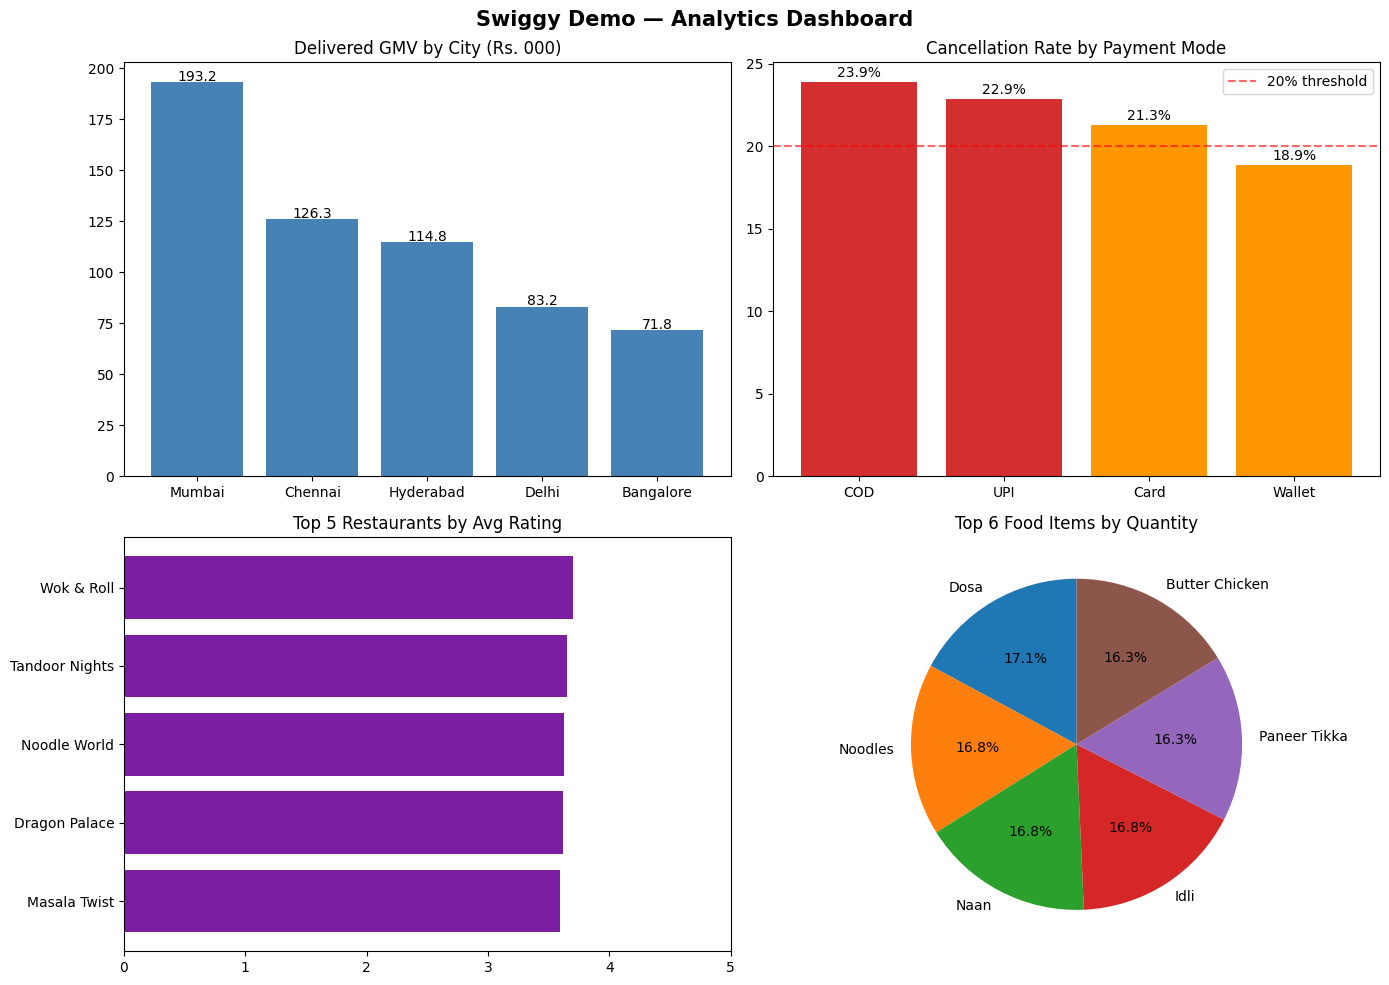

Dashboard saved.


In [19]:
# ── Cell 17: Visualization Dashboard ──────────────────────────────────────────
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle("Swiggy Demo — Analytics Dashboard", fontsize=15, fontweight="bold")

gmv_df = pd.read_sql("""
SELECT r.city, ROUND(SUM(o.total_amount)/1000, 1) AS gmv_k
FROM orders o JOIN restaurants r ON o.restaurant_id = r.id
WHERE o.status = 'delivered' GROUP BY r.city ORDER BY gmv_k DESC;""", ro_conn)
axes[0,0].bar(gmv_df["city"], gmv_df["gmv_k"], color="steelblue")
axes[0,0].set_title("Delivered GMV by City (Rs. 000)")
for i, v in enumerate(gmv_df["gmv_k"]): axes[0,0].text(i, v+0.5, str(v), ha="center")

cancel_df = pd.read_sql("""
SELECT payment_mode,
ROUND(100.0*SUM(CASE WHEN status='cancelled' THEN 1 ELSE 0 END)/COUNT(*),1) AS pct
FROM orders GROUP BY payment_mode ORDER BY pct DESC;""", ro_conn)
colors = ["#d32f2f" if v>22 else "#ff9800" if v>18 else "#388e3c" for v in cancel_df["pct"]]
axes[0,1].bar(cancel_df["payment_mode"], cancel_df["pct"], color=colors)
axes[0,1].axhline(y=20, color="red", linestyle="--", alpha=0.6, label="20% threshold")
axes[0,1].set_title("Cancellation Rate by Payment Mode"); axes[0,1].legend()
for i, v in enumerate(cancel_df["pct"]): axes[0,1].text(i, v+0.3, f"{v}%", ha="center")

rev_df = pd.read_sql("""
SELECT r.name, ROUND(AVG(rv.rating),2) AS avg_rating
FROM reviews rv JOIN restaurants r ON rv.restaurant_id = r.id
GROUP BY r.name HAVING COUNT(rv.id) >= 10 ORDER BY avg_rating DESC LIMIT 5;""", ro_conn)
axes[1,0].barh(rev_df["name"][::-1], rev_df["avg_rating"][::-1], color="#7b1fa2")
axes[1,0].set_xlim(0, 5); axes[1,0].set_title("Top 5 Restaurants by Avg Rating")

item_df = pd.read_sql("""
SELECT item_name, SUM(quantity) AS total
FROM order_items GROUP BY item_name ORDER BY total DESC LIMIT 6;""", ro_conn)
axes[1,1].pie(item_df["total"], labels=item_df["item_name"], autopct="%1.1f%%", startangle=90)
axes[1,1].set_title("Top 6 Food Items by Quantity")

plt.tight_layout()
plt.savefig("text2sql_dashboard.png", dpi=120, bbox_inches="tight")
plt.show()
print("Dashboard saved.")

---
# Section 11 — 

## Practice Questions

### Level 1 — Single Table
1. How many customers joined in the last 30 days?
2. Which restaurant has the highest rating?
3. How many orders were placed via UPI?

### Level 2 — Aggregations + Joins
4. Average order value by cuisine type?
5. Which city has the most customers?
6. Monthly order count for the past 3 months?
7. Which restaurants have zero reviews?

### Level 3 — Advanced SQL
8. Repeat customer rate? (customers with 2+ orders)
9. Which day of the week has the highest GMV?
10. Customers who spent more than Rs. 5,000 total?

### Level 4 — Engineer the Fix
11. Find a query that generates wrong SQL. Identify .
12. Add a few-shot example that fixes the problem.
13. Verify your fix works.

### Reflection
- Which component had the biggest accuracy impact?
- What would you change in `SCHEMA_DESCRIPTION`?
- What security layers would you add in production?

In [21]:
# ── Cell 18: Exercise Runner ───────────────────────────────────────────────────


MY_QUESTION = "What is the average order value by cuisine type?"

print(f"Running: {MY_QUESTION!r}")
print()
result = text_to_sql_pipeline(MY_QUESTION)

if result["success"]:
    print()
    print(f"Tables used  : {result['tables_used']}")
    print(f"Generated SQL: {result['sql']}")
    print()
    print("Raw Data:")
    print(result["data"].to_string(index=False))
    print()
    print("Business Insight:")
    print(result["answer"])
else:
    print(f"Pipeline failed: {result['error']}")
    print()
    print("Debug hints:")
    print("  1. Is the column name in SCHEMA_DESCRIPTION?")
    print("  2. Does a few-shot example cover this query pattern?")
    print("  3. Did Schema RAG pick the right tables?")

Running: 'What is the average order value by cuisine type?'

[1/4] Schema RAG...
      Tables: ['order_items', 'restaurants', 'reviews']
[2/4] SQL Generation...
      SQL: SELECT r.cuisine, ROUND(AVG(o.total_amount), 2) AS avg_order_value FRO
[3/4] Validate + Execute...
Pipeline failed: Attempt 1: BLOCKED - Forbidden keyword: --

Debug hints:
  1. Is the column name in SCHEMA_DESCRIPTION?
  2. Does a few-shot example cover this query pattern?
  3. Did Schema RAG pick the right tables?


---
# Summary

```
What we built:
  1. SQLite database    - realistic Swiggy schema, 1,200 orders
  2. Schema description - column comments, FK labels, enum values
  3. extract_sql()      - handles any LLM output format
  4. Security           - SELECT whitelist + read-only connection
  5. Auto-fix           - error -> LLM fix -> retry (80% success)
  6. Few-shot prompt    - 5 examples teach domain conventions
  7. Schema RAG         - qwen3-embedding finds relevant tables (scales to 500+)
  8. Interpretation     - DataFrame -> business narrative
  9. Full pipeline      - one function, all 4 components integrated
  10. Dashboard         - 4-chart matplotlib visualization
```

## Production Checklist

- [ ] Read-only DB connection
- [ ] SELECT-only whitelist validation
- [ ] Query timeout (5s max)
- [ ] Row limit (LIMIT 1000)
- [ ] Rate limiting per user
- [ ] Audit logging of generated SQL
- [ ] Schema RAG for 20+ tables
- [ ] Few-shot examples for top 5 query patterns
- [ ] Read replica (never Text2SQL on primary DB)

---
**Next:** `35_text2sql_with_langchain_end_to_end_student.ipynb`